# Bitmapper playground

Iterate on the retro bitmap filter visually. All the actual logic lives in the `bitmapper` package (not in this notebook) so it stays unit-testable.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from bitmapper import BitmapFilterConfig, apply_bitmap_filter, list_palettes

print("Available fixed palettes:", list_palettes())

Available fixed palettes: ['appleii', 'c64', 'cga', 'ega', 'gameboy', 'monochrome_amber', 'monochrome_green', 'msx', 'nes', 'pico8', 'sepia', 'teletext', 'vga256', 'zxspectrum']


## Plot helper

Every comparison cell below renders a list of items through the filter and lays them out 3-per-row. `plot_grid` does that once so the cells only need to say *what varies*.

In [2]:
def plot_grid(items, config_fn, title_fn, ncols=3, cell_size=4):
    """Run source_image through apply_bitmap_filter for each item and plot
    the results in a ceil-divided grid with ``ncols`` columns per row.

    ``config_fn(item)`` builds the BitmapFilterConfig to use for ``item``;
    ``title_fn(item)`` labels its subplot.
    """
    nrows = -(-len(items) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell_size * ncols, cell_size * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, item in zip(axes, items):
        result = apply_bitmap_filter(source_image, config_fn(item))
        ax.imshow(result.output)
        ax.set_title(title_fn(item))
        ax.axis("off")

    for ax in axes[len(items):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## Load a source image

Point `IMAGE_PATH` at a real photo if you have one. If it's missing, a synthetic gradient/checker test image is generated instead.

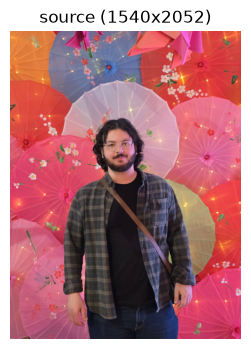

In [3]:
IMAGE_PATH = Path.cwd().parent / "_images" / "20260913_170036.jpg"

if IMAGE_PATH.exists():
    source_image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
else:
    print(f"{IMAGE_PATH} not found, generating a synthetic test image instead.")
    size = 400
    yy, xx = np.mgrid[0:size, 0:size]
    r = (xx / size * 255).astype(np.uint8)
    g = (yy / size * 255).astype(np.uint8)
    b = (((xx + yy) / (2 * size)) * 255).astype(np.uint8)
    source_image = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(4, 4))
plt.imshow(source_image)
plt.title(f"source ({source_image.shape[1]}x{source_image.shape[0]})")
plt.axis("off")
plt.show()

## Try a single configuration

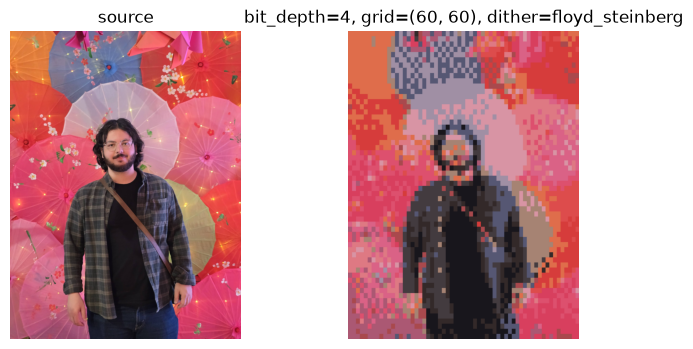

colors used: 16


In [4]:
photo_size = (source_image.shape[1], source_image.shape[0])
output_size = photo_size

config = BitmapFilterConfig(
    output_size=output_size,
    grid_size=(60, 60),
    bit_depth=4,
    block_sampling="average",
    palette_mode="auto",
    palette_algorithm="median_cut",
    dither="floyd_steinberg",
)

result = apply_bitmap_filter(source_image, config)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(source_image)
axes[0].set_title("source")
axes[0].axis("off")
axes[1].imshow(result.output)
axes[1].set_title(f"bit_depth={config.bit_depth}, grid={config.grid_size}, dither={config.dither}")
axes[1].axis("off")
plt.show()

print("colors used:", len(set(map(tuple, result.output.reshape(-1, 3)))))

## Compare bit depths side by side

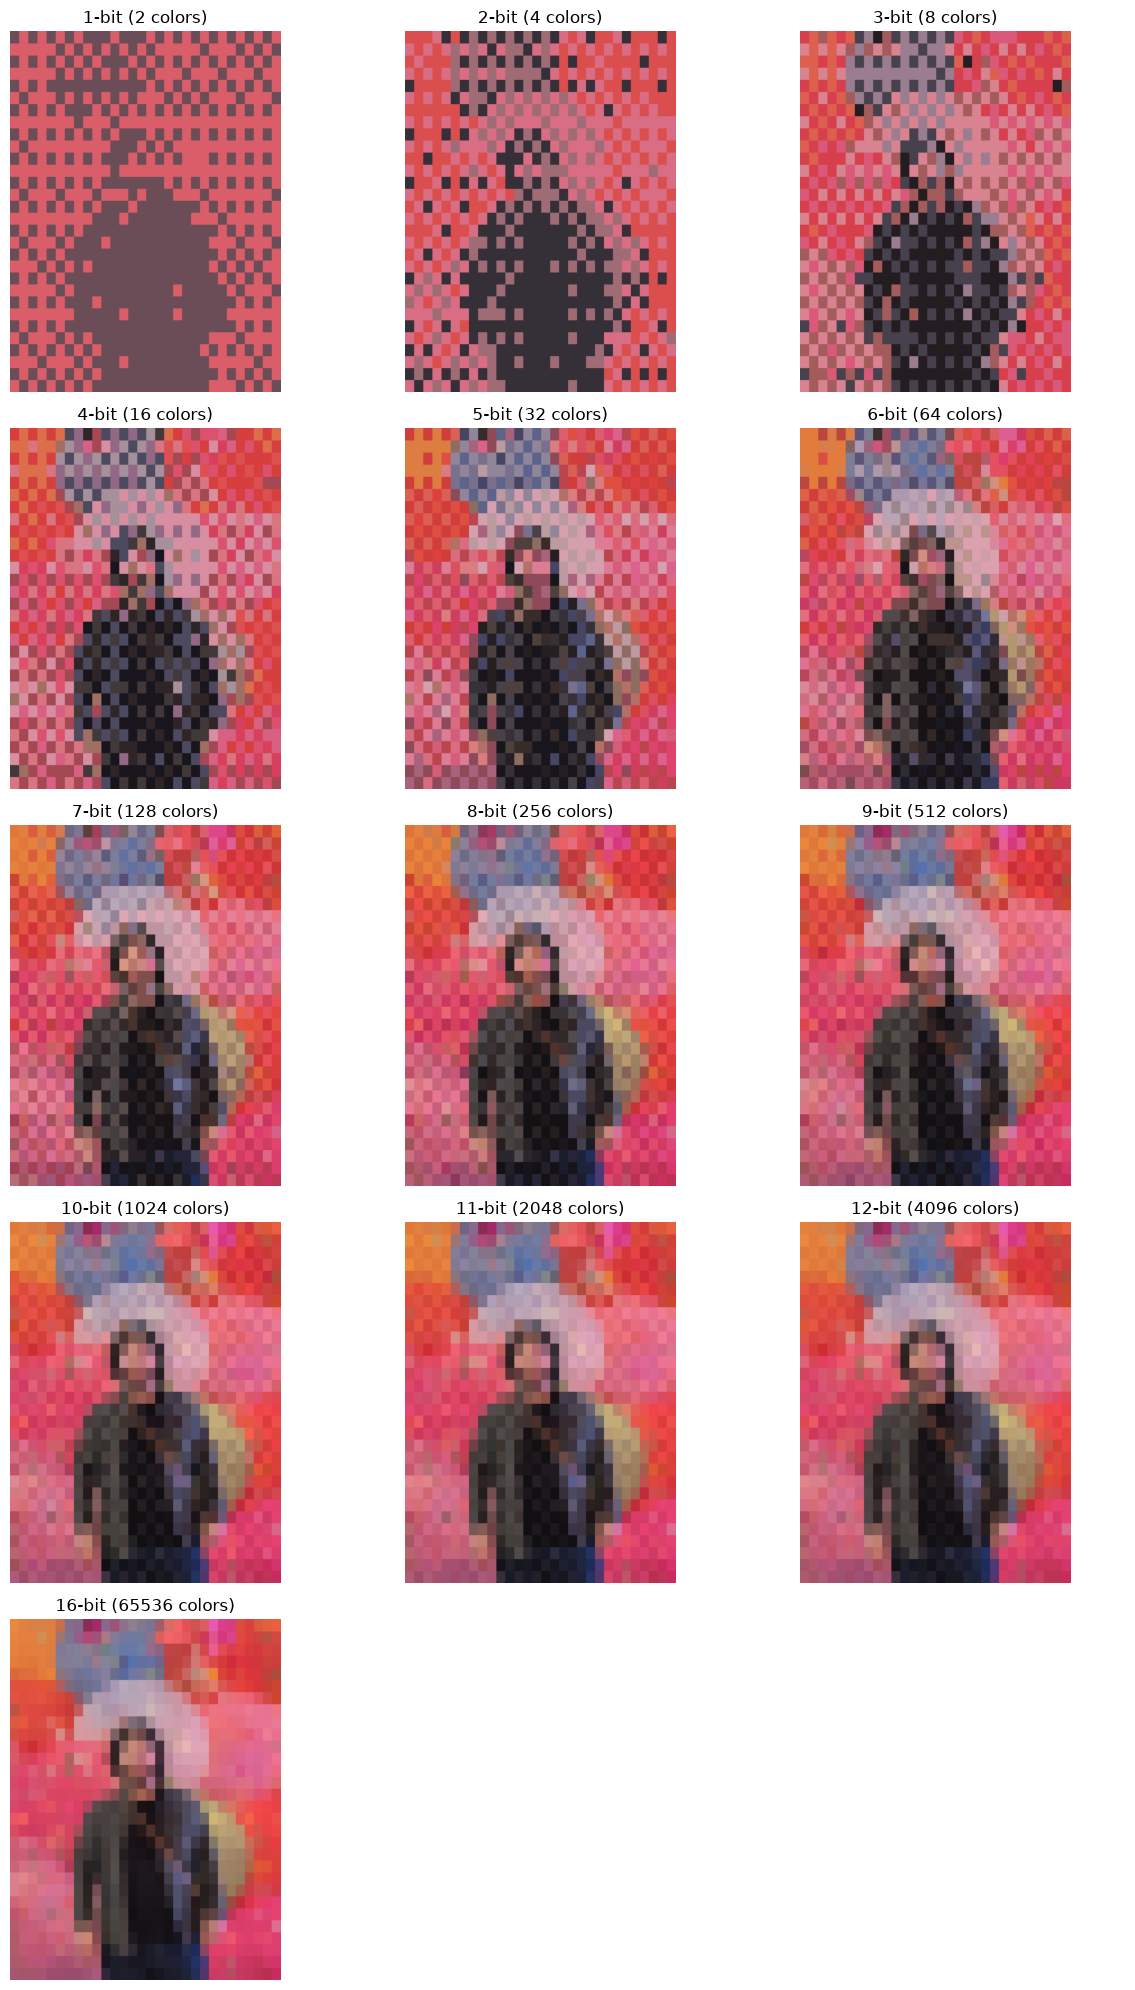

In [5]:
bit_depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16]  # 16+ is "true color" passthrough (no palette quantization)

plot_grid(
    bit_depths,
    config_fn=lambda depth: BitmapFilterConfig(output_size=output_size, grid_size=(30, 30), bit_depth=depth, dither="ordered"),
    title_fn=lambda depth: f"{depth}-bit ({2 ** depth} colors)",
)

## Compare dithering methods

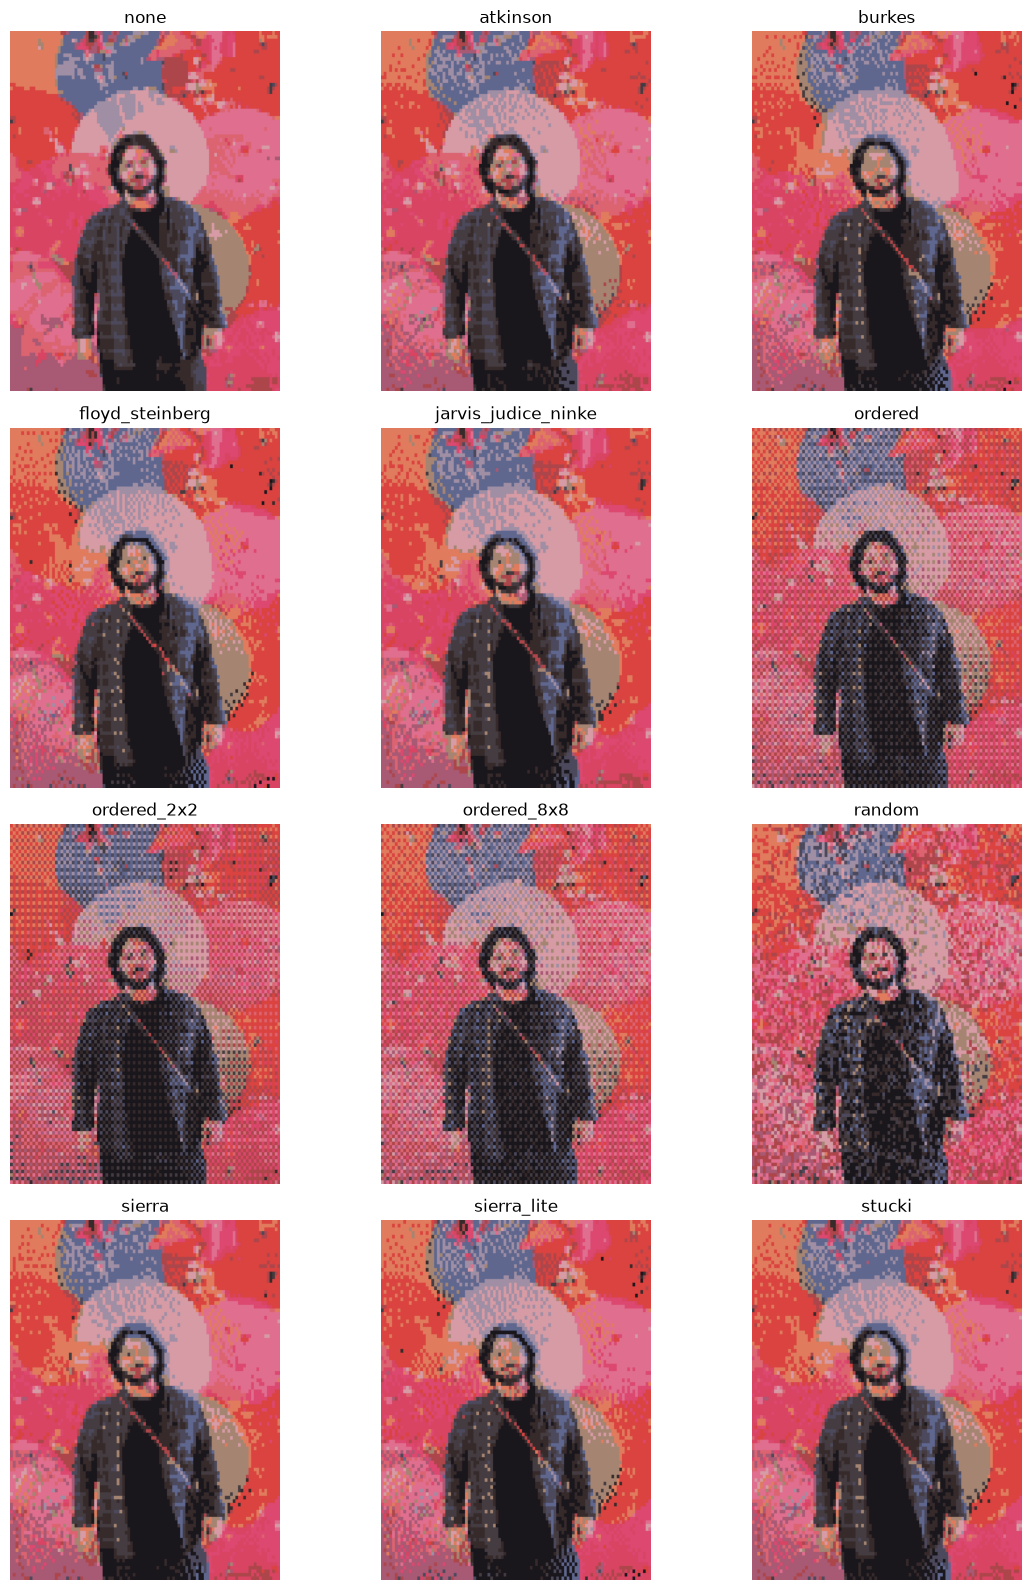

In [6]:
from bitmapper.dither import list_methods as list_dither_methods

dither_methods = list_dither_methods()

plot_grid(
    dither_methods,
    config_fn=lambda method: BitmapFilterConfig(output_size=output_size, grid_size=(100, 100), bit_depth=4, dither=method),
    title_fn=lambda method: method,
)

## Fixed retro palettes

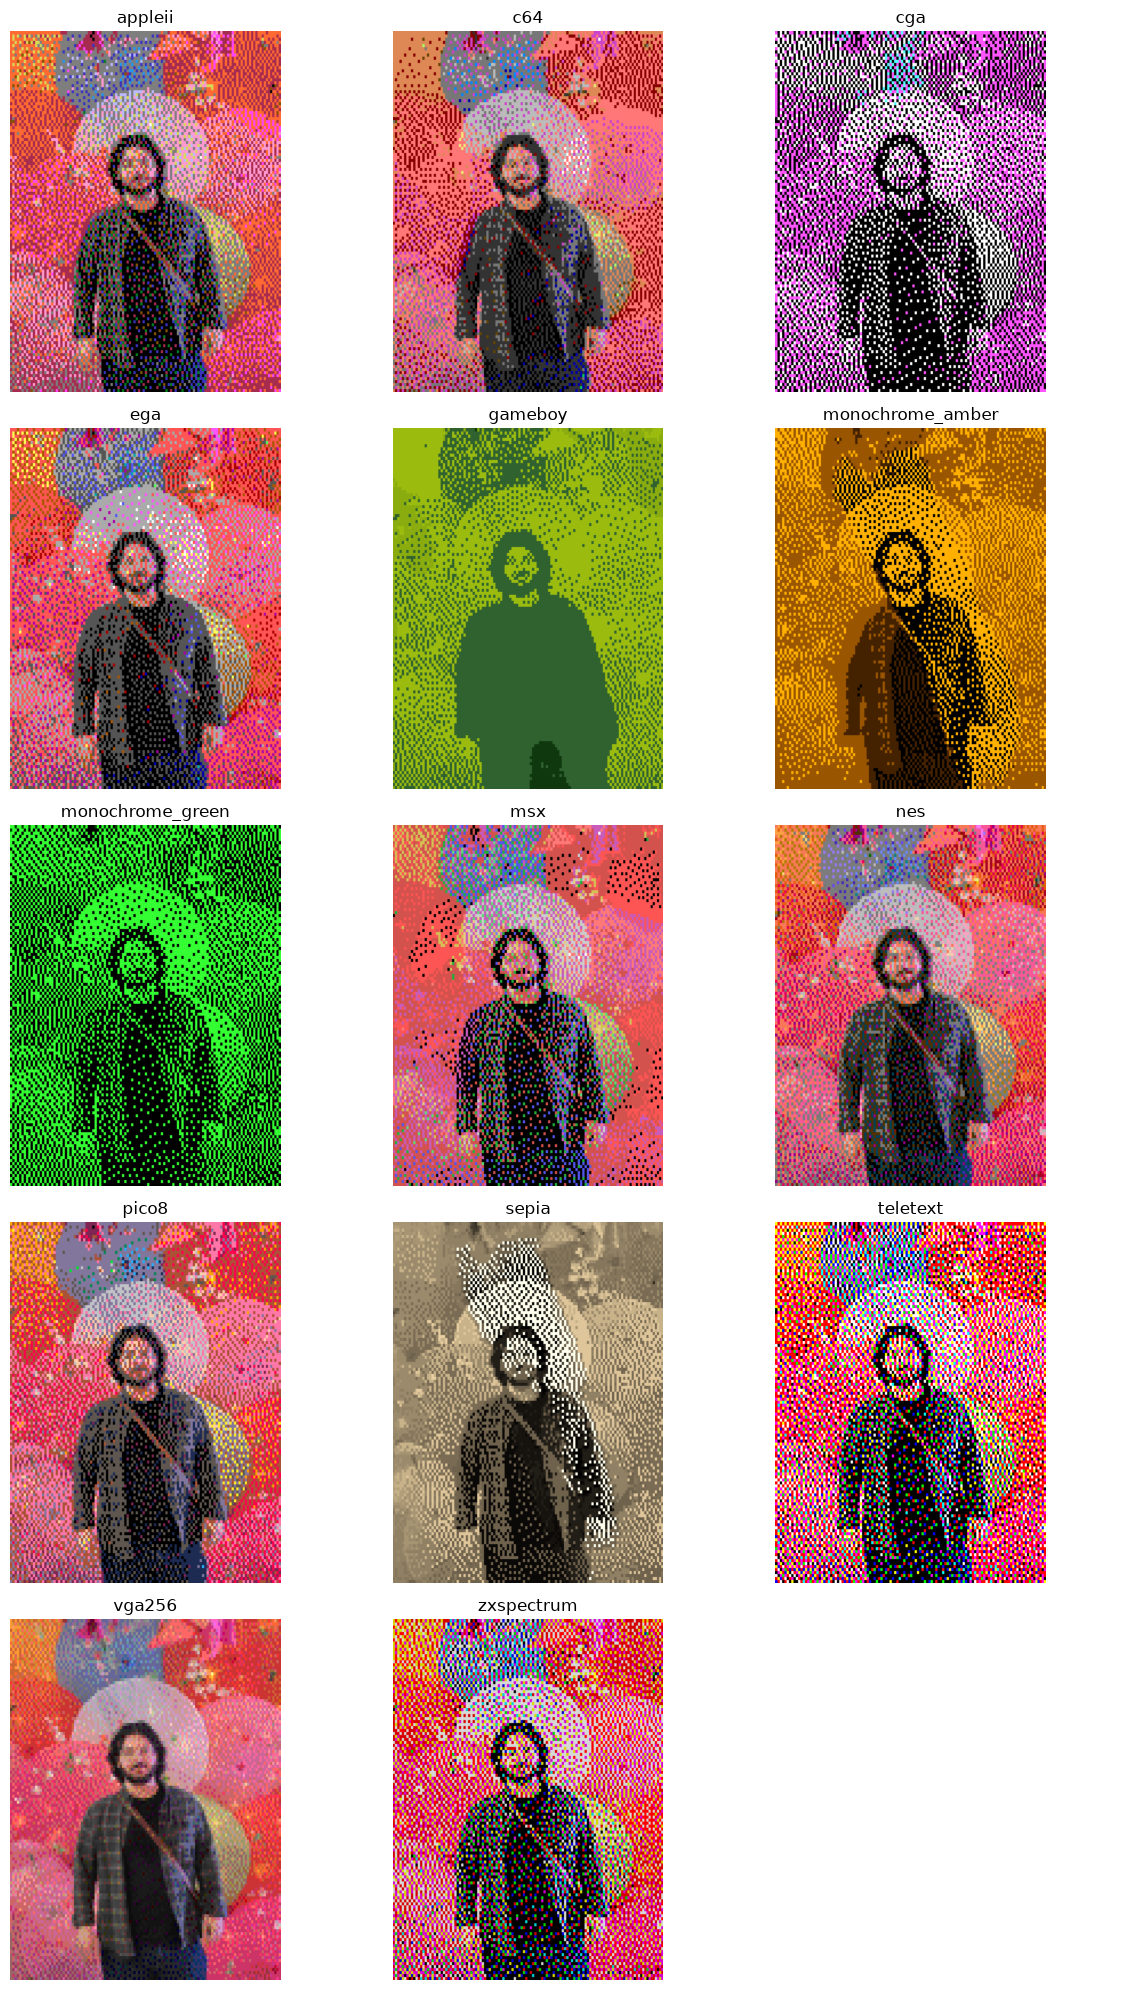

In [7]:
palette_names = list_palettes()

plot_grid(
    palette_names,
    config_fn=lambda name: BitmapFilterConfig(
        output_size=output_size, grid_size=(120, 120), bit_depth=8,
        palette_mode="fixed", fixed_palette=name, dither="floyd_steinberg",
    ),
    title_fn=lambda name: name,
)

## Grid resolution / block size

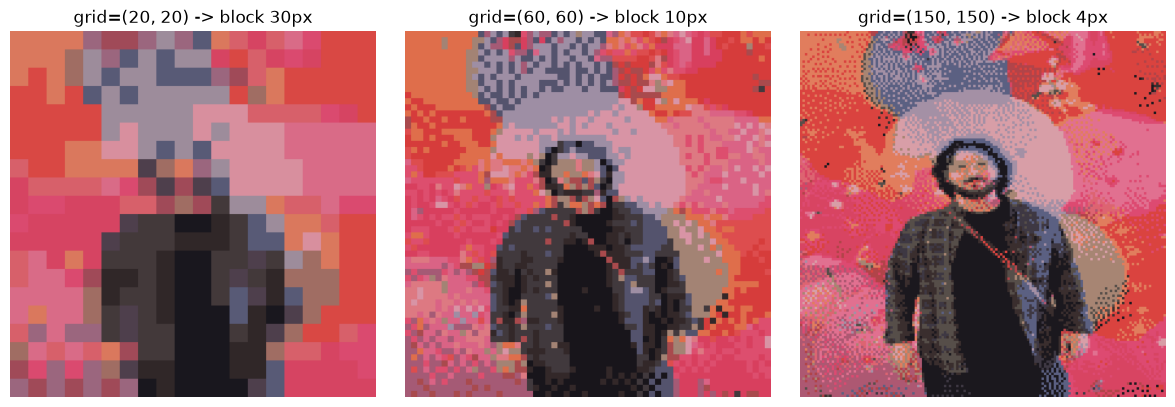

In [8]:
grid_sizes = [(20, 20), (60, 60), (150, 150)]

plot_grid(
    grid_sizes,
    config_fn=lambda gsize: BitmapFilterConfig(output_size=(600, 600), grid_size=gsize, bit_depth=4, dither="floyd_steinberg"),
    title_fn=lambda gsize: f"grid={gsize} -> block {600 // gsize[0]}px",
)

## Dither strength

`dither_strength` (0-1) scales how much dithering pattern gets applied: 0 behaves exactly like `dither="none"`, 1 is full strength.

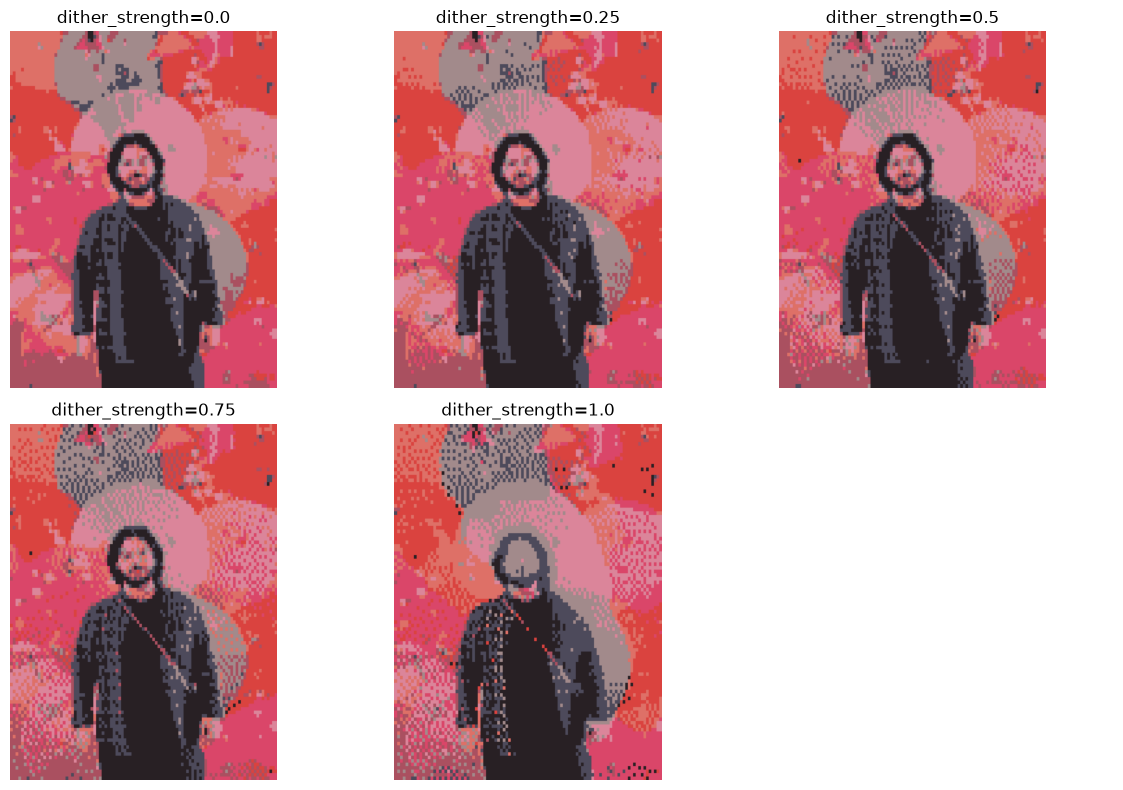

In [9]:
dither_strengths = [0.0, 0.25, 0.5, 0.75, 1.0]

plot_grid(
    dither_strengths,
    config_fn=lambda strength: BitmapFilterConfig(
        output_size=output_size, grid_size=(100, 100), bit_depth=3,
        dither="floyd_steinberg", dither_strength=strength,
    ),
    title_fn=lambda strength: f"dither_strength={strength}",
)

## CRT scanlines

`scanlines` (0-1) darkens alternate output rows for a CRT effect, applied after upscaling.

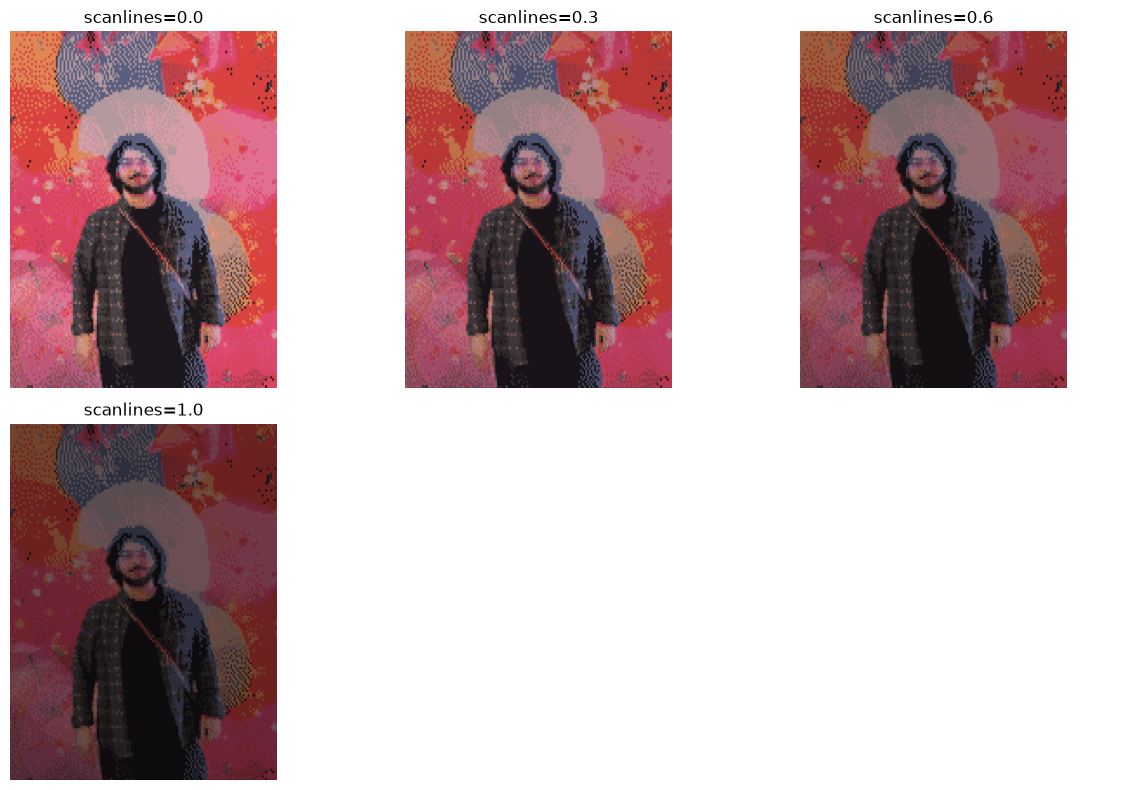

In [10]:
scanline_strengths = [0.0, 0.3, 0.6, 1.0]

plot_grid(
    scanline_strengths,
    config_fn=lambda strength: BitmapFilterConfig(
        output_size=output_size, grid_size=(150, 150), bit_depth=4,
        dither="floyd_steinberg", scanlines=strength,
    ),
    title_fn=lambda strength: f"scanlines={strength}",
)

## Pixel grid gap (gutters)

`grid_gap_px` draws a gutter of `grid_gap_color` between blocks, for a separated-tile look.

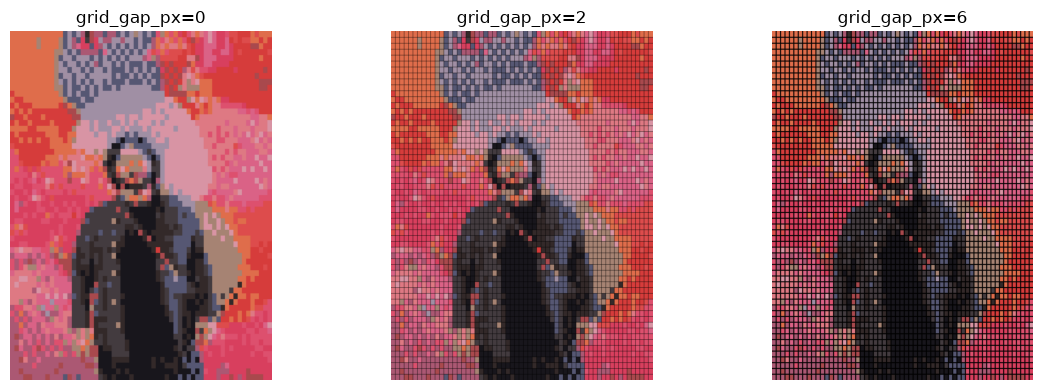

In [11]:
gap_sizes = [0, 2, 6]

plot_grid(
    gap_sizes,
    config_fn=lambda gap: BitmapFilterConfig(
        output_size=output_size, grid_size=(60, 60), bit_depth=4,
        dither="floyd_steinberg", grid_gap_px=gap,
    ),
    title_fn=lambda gap: f"grid_gap_px={gap}",
)

## Contrast / saturation / gamma

Pre-adjustments applied to the canvas before quantization. Each is 1.0 at no-op.

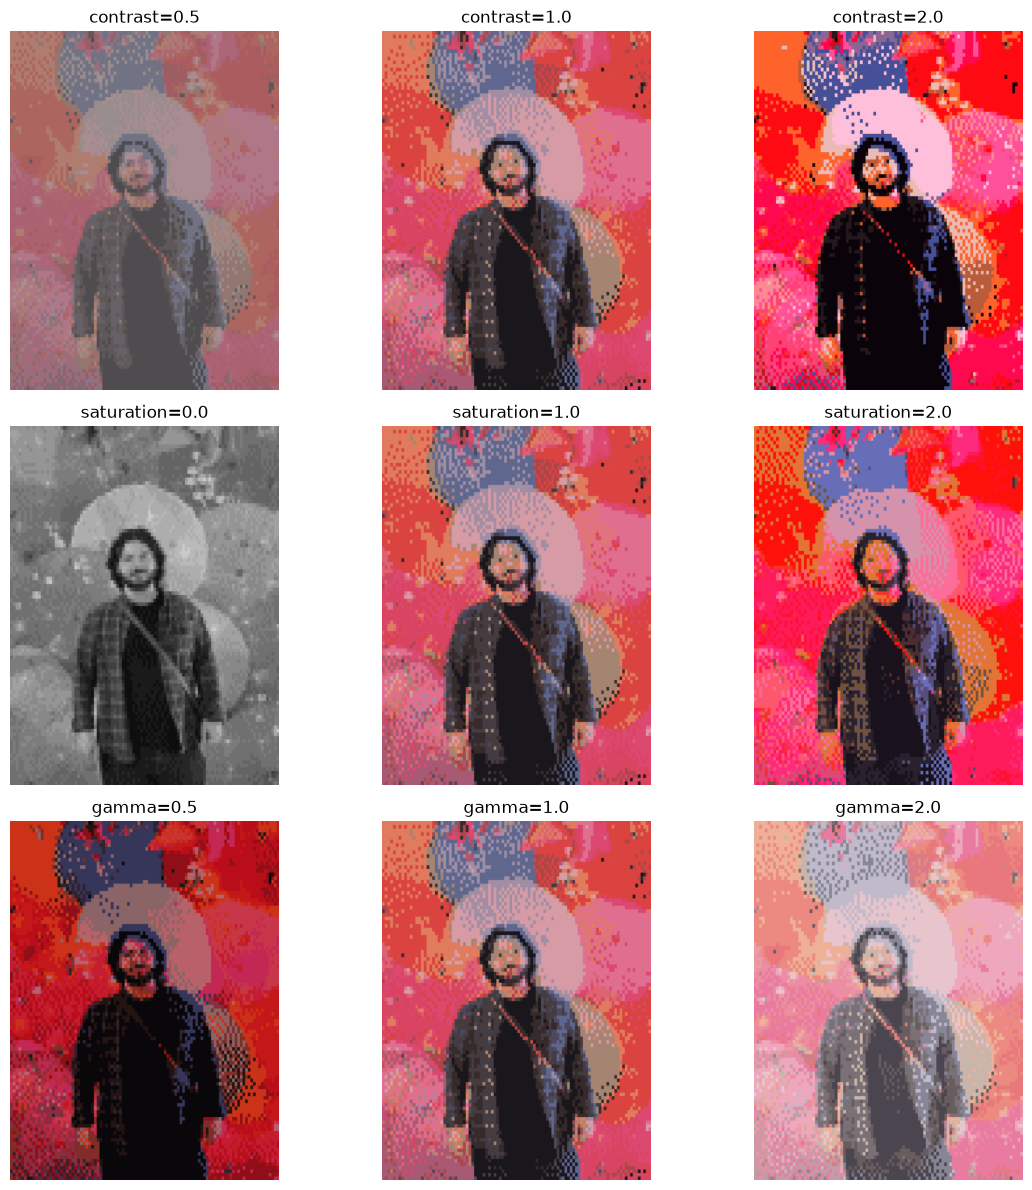

In [12]:
adjustments_to_try = [
    ("contrast", 0.5), ("contrast", 1.0), ("contrast", 2.0),
    ("saturation", 0.0), ("saturation", 1.0), ("saturation", 2.0),
    ("gamma", 0.5), ("gamma", 1.0), ("gamma", 2.0),
]

plot_grid(
    adjustments_to_try,
    config_fn=lambda pv: BitmapFilterConfig(
        output_size=output_size, grid_size=(100, 100), bit_depth=4,
        dither="floyd_steinberg", **{pv[0]: pv[1]},
    ),
    title_fn=lambda pv: f"{pv[0]}={pv[1]}",
)

## Fixed palette capped by bit_depth

`bit_depth` now caps a fixed palette's color count too (evenly-spaced subsample), not just auto-generated palettes.

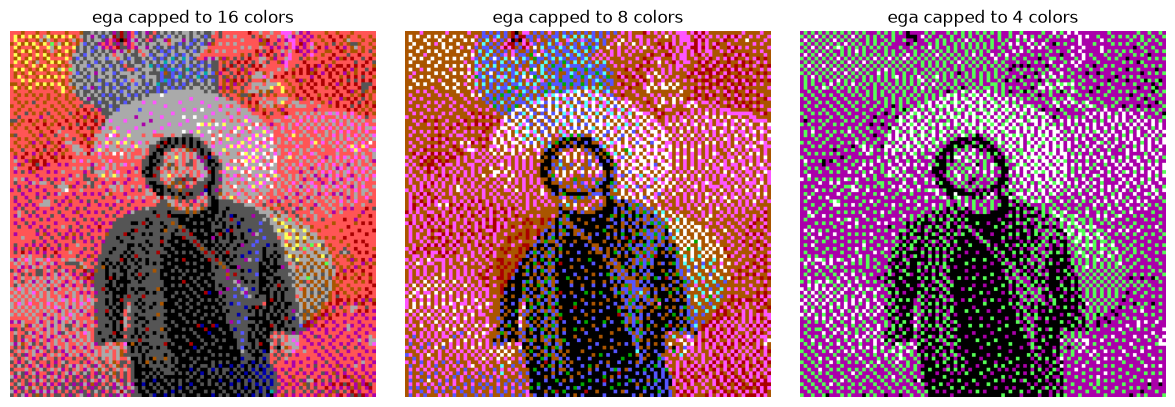

In [13]:
budget_bit_depths = [4, 3, 2]  # ega has 16 colors natively; cap to 16, 8, 4

plot_grid(
    budget_bit_depths,
    config_fn=lambda depth: BitmapFilterConfig(
        output_size=(600, 600), grid_size=(100, 100), bit_depth=depth,
        palette_mode="fixed", fixed_palette="ega", dither="floyd_steinberg",
    ),
    title_fn=lambda depth: f"ega capped to {2 ** depth} colors",
)

## Custom palettes

`palette_mode="custom"` quantizes onto any user-supplied list of RGB tuples — not just the curated fixed palettes.

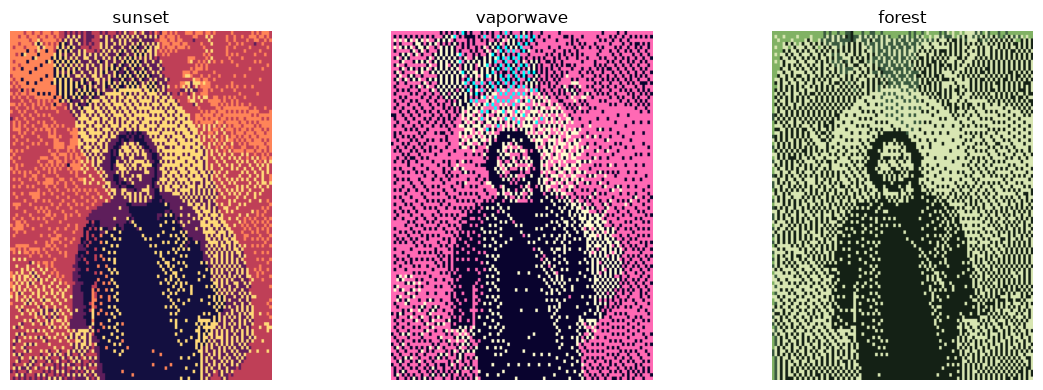

In [14]:
custom_palettes = {
    "sunset": [(19, 15, 64), (94, 30, 91), (191, 63, 87), (255, 132, 88), (255, 218, 120)],
    "vaporwave": [(9, 3, 46), (255, 105, 180), (0, 255, 255), (255, 253, 208)],
    "forest": [(20, 33, 21), (58, 90, 64), (129, 178, 100), (216, 230, 178)],
}

plot_grid(
    list(custom_palettes.items()),
    config_fn=lambda kv: BitmapFilterConfig(
        output_size=output_size, grid_size=(100, 100), bit_depth=8,
        palette_mode="custom", custom_palette=kv[1], dither="floyd_steinberg",
    ),
    title_fn=lambda kv: kv[0],
)